In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
ckpt_path1 = "/mnt/pengyanxin/Megatron-LLaMA/checkpoints/iter_0010083/mp_rank_00_001/distrib_optim.pt"
ckpt1 = torch.load(ckpt_path1, map_location='cpu')

ckpt_path2 = "/mnt/pengyanxin/Megatron-LLaMA/checkpoints/iter_0010084/mp_rank_00_001/distrib_optim.pt"
ckpt2 = torch.load(ckpt_path2, map_location='cpu')
print(ckpt2.keys())
state_dict1 = ckpt1[0]['param']
state_dict2 = ckpt2[0]['param']


print(state_dict1)
print(state_dict2)

diff_distrib_optim = state_dict2 - state_dict1
print(state_dict1 - state_dict2)

dict_keys([0, 1])
tensor([-0.0091, -0.0154, -0.0292,  ..., -0.0034,  0.0038, -0.0085])
tensor([-0.0091, -0.0154, -0.0292,  ..., -0.0034,  0.0038, -0.0085])
tensor([-8.6520e-07, -1.7863e-06, -8.1025e-07,  ...,  1.5134e-06,
         2.3986e-06,  1.1548e-07])


In [3]:
print(diff_distrib_optim.dtype)

torch.float32


In [4]:
def tensors_to_numpy(data):
    if isinstance(data, dict): 
        return {key: tensors_to_numpy(value) for key, value in data.items()}
    elif isinstance(data, torch.Tensor): 
        return data.cpu().numpy()
    else: 
        return data
    
diff_state_dict_numpy = tensors_to_numpy(diff_distrib_optim)
print(diff_state_dict_numpy)

[ 8.6519867e-07  1.7862767e-06  8.1025064e-07 ... -1.5133992e-06
 -2.3986213e-06 -1.1548400e-07]


In [5]:

def plot_non_zero_1d(tensor_diff, title="Non-zero Differences Plot", max_points=1000):
    # Create a mask for non-zero values
    non_zero_indices = np.nonzero(tensor_diff)[0]
    values = tensor_diff[non_zero_indices]
    
    # Downsample if there are too many points
    if len(non_zero_indices) > max_points:
        indices = np.linspace(0, len(non_zero_indices) - 1, max_points).astype(int)
        non_zero_indices = non_zero_indices[indices]
        values = values[indices]
    
    # Plot the graph
    plt.figure(figsize=(10, 6))
    plt.plot(non_zero_indices, values, 'o', label='Non-zero differences')
    plt.title(title)
    plt.xlabel("Index")
    plt.ylabel("Difference Value")
    plt.legend()
    plt.show()

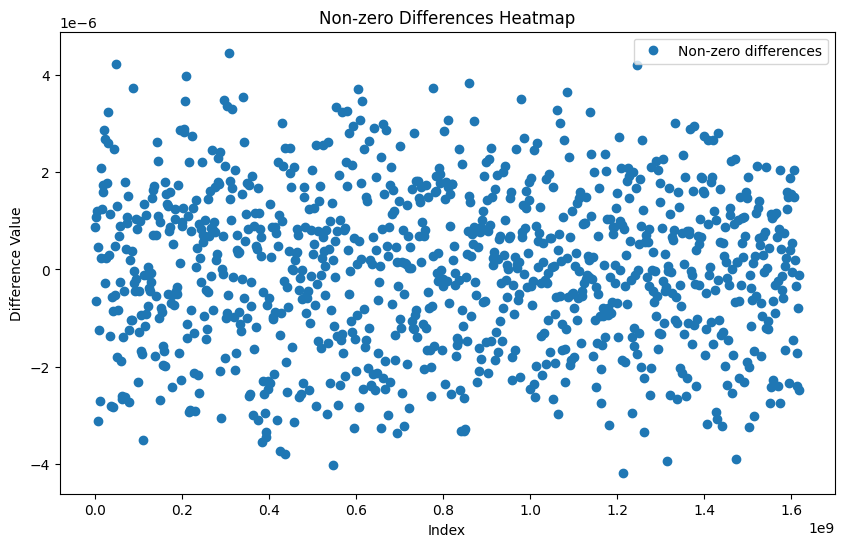

In [6]:
plot_non_zero_1d(diff_state_dict_numpy, title="Non-zero Differences Heatmap")

In [7]:
def calculate_percentage_of_changes(tensor_diff):
    # Flatten the tensor to a 1D array
    
    # Count the number of non-zero elements
    num_non_zero = (tensor_diff != 0).sum()
    
    # Calculate the total number of elements
    total_elements = tensor_diff.size
    
    # Compute the percentage of changed elements
    percentage_changed = (num_non_zero / total_elements) * 100
    
    return percentage_changed

# Example usag
tensor_diff_to_plot = diff_state_dict_numpy
percentage_changed = calculate_percentage_of_changes(tensor_diff_to_plot)
print(f"Percentage of changed :{percentage_changed:.2f}%")

Percentage of changed :99.97%
